# Data Preparation Pipeline
---
### Field Data · Sentinel-1/2 · DEM · Train-Test Split

## Configuration

### Imports

In [1]:
from datetime import datetime
import json
import os
import random
import warnings

import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from shapely.geometry import Point, Polygon
from sklearn.model_selection import train_test_split

from indices import add_s2_indices, add_s1_indices

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


### Seeds & Global constants

In [2]:
# Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths
FOLDER = 'data/sen'
INPUT_CSV_FIELD = f'{FOLDER}/dataset_agb_mission_janvier_2026.csv'
INPUT_EXCEL_FIELD = f'{FOLDER}/SYNTHESE_DATA_MCA.xlsx'
OUTPUT_CSV_FIELD = f'{FOLDER}/dataset_agb_sedhiou_mission_janvier_2026.csv'
SENEGAL_GEOJSON = f'{FOLDER}/gadm41_SEN_0.json'

SAVE_DATE = datetime.now().strftime("%Y-%m-%d")
INPUT_CSV_SAT = f'{FOLDER}/dataset_agb_sedhiou_mission_janvier_2026.csv'
OUTPUT_CSV_SAT = f'{FOLDER}/sen-biomass-dataset_s1_s2_dem_{SAVE_DATE}.csv'
OUTPUT_GEOJSON = f'{FOLDER}/sen-biomass-dataset_s1_s2_dem_{SAVE_DATE}.geojson'

TRAIN_FILE = f'{FOLDER}/train.csv'
TEST_FILE = f'{FOLDER}/test.csv'

LAND_AREA_PATH = f"{FOLDER}/land_area.txt"

# Parameters
TARGET = 'agb'
CRSP = 'epsg:32628'
CRSG = 'epsg:4326'
TEST_SIZE = 0.2
THRESHOLD = 15      # max cloud cover percentage for S2
RADIUS = 16      # buffer radius in meters
NODATA = -9999
CAGB_THRESHOLD = 200
EPS = 1e-9

COLS_FIELD = ['inventory_date', 'latitude_proj', 'longitude_proj', 'agb']

# AGB carbon bins
BINS = [0, 3, 6, 9, 12, 15, float("inf")]
LABELS = ["OL", "S", "YRF", "LDF", "MDF", "HDF"]

# Satellite bands
S1_BANDS = ['VV', 'VH']
S2_BANDS = ['B2', 'B3', 'B4', 'B8', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'B9', 'B1']
DEM_BANDS = ['elevation']
COORDINATES = ['latitude_proj', 'longitude_proj']

print("Configuration loaded.")


Configuration loaded.


## Field Data

### Load & harmonize columns

In [3]:
# CSV (January 2026 Mission)
first_data = pd.read_csv(INPUT_CSV_FIELD)
first_data_copy = first_data.copy()
first_data_copy.rename(columns={
    'Date' : 'inventory_date',
    'Y' : 'latitude_proj',
    'X' : 'longitude_proj',
    'AGB_tha_(Model_Chave_al)' : 'agb'
}, inplace=True)
first_data_copy = first_data_copy[COLS_FIELD]

# Excel (MCA Synthesis)
second_data = pd.read_excel(INPUT_EXCEL_FIELD, header=2, nrows=40)
second_data_copy = second_data.copy()
second_data_copy.rename(columns={
    'DATE_DONNEES' : 'inventory_date',
    'Y' : 'latitude_proj',
    'X' : 'longitude_proj',
    'AGB_tha_(avec Model_Chave_al).1' : 'agb'
}, inplace=True)
second_data_copy = second_data_copy[COLS_FIELD]

print("First dataset:")
print(first_data_copy.info())
print("\nSecond dataset:")
print(second_data_copy.info())


First dataset:
<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inventory_date  128 non-null    str    
 1   latitude_proj   128 non-null    int64  
 2   longitude_proj  128 non-null    int64  
 3   agb             128 non-null    float64
dtypes: float64(1), int64(2), str(1)
memory usage: 4.1 KB
None

Second dataset:
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   inventory_date  40 non-null     datetime64[us]
 1   latitude_proj   40 non-null     int64         
 2   longitude_proj  40 non-null     int64         
 3   agb             40 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 1.4 KB
None


### Merge, deduplication & categorization

In [4]:
# Merge both sources
data_field_combined = pd.concat([first_data_copy, second_data_copy], ignore_index=True)

# Round AGB and compute carbon AGB (CAGB)
data_field_combined.loc[:, "agb"] = round(data_field_combined.agb, 2)
data_field_combined.loc[:, "cagb"] = round(data_field_combined.agb * 0.47, 2)

# Remove exact duplicates
data_field_combined = data_field_combined.drop_duplicates(
    subset=['inventory_date', 'longitude_proj', 'latitude_proj'], keep=False
)

# Filter extreme CAGB values and assign carbon categories
df_filtered = data_field_combined[data_field_combined.cagb < CAGB_THRESHOLD].copy()
df_filtered["cagb_category"] = pd.cut(
    df_filtered.cagb, bins=BINS, labels=LABELS, include_lowest=True)
df_filtered["HCS"] = df_filtered.cagb_category.apply(
    lambda x: "HCS" if x in LABELS[-3:] else "non-HCS"
)
df_filtered.reset_index(drop=True, inplace=True)

print(f"{len(df_filtered)} observations after merge and filtering.")
df_filtered.info()


168 observations after merge and filtering.
<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   inventory_date  168 non-null    object  
 1   latitude_proj   168 non-null    int64   
 2   longitude_proj  168 non-null    int64   
 3   agb             168 non-null    float64 
 4   cagb            168 non-null    float64 
 5   cagb_category   168 non-null    category
 6   HCS             168 non-null    str     
dtypes: category(1), float64(2), int64(2), object(1), str(1)
memory usage: 8.4+ KB


### Spatial filtering (points within Senegal)

In [5]:
# Load Senegal boundary
gdf_senegal = gpd.read_file(SENEGAL_GEOJSON)

# Build GeoDataFrame from projected coordinates
df_filtered["coordinates"] = df_filtered.apply(
    lambda row: Point(row['longitude_proj'], row['latitude_proj']), axis=1
)
df_filtered = gpd.GeoDataFrame(df_filtered, geometry='coordinates', crs=CRSP)

# Reproject to WGS84
df_filtered = df_filtered.to_crs(CRSG)

# Keep only points falling inside Senegal
df_joined = gpd.sjoin(df_filtered, gdf_senegal, how="inner", predicate="within")

COLS_OUT = COLS_FIELD + ['cagb', 'cagb_category', 'HCS']
df_filtered = df_joined[COLS_OUT].copy()

print(f"{len(df_filtered)} points located inside Senegal.")
pd.DataFrame(df_filtered).head()


168 points located inside Senegal.


,inventory_date,latitude_proj,longitude_proj,agb,cagb,cagb_category,HCS
0,2026-01-15,1791714,389501,0.00,0.00,OL,non-HCS
1,2026-01-15,1785136,391868,0.00,0.00,OL,non-HCS
2,2026-01-15,1785256,390230,0.00,0.00,OL,non-HCS
3,2026-01-15,1791718,389640,4.67,2.19,OL,non-HCS
4,2026-01-15,1786002,390754,11.66,5.48,S,non-HCS


### LAND AREA

In [6]:
plots = df_filtered.shape[0]
area_ha = np.pi * (RADIUS**2) / 10000
landscape_area = np.round(plots * area_ha, 2)
print(f"Landscape area : {landscape_area:.2f} ha")

with open(LAND_AREA_PATH, "w", encoding="utf-8") as f:
    f.write(str(landscape_area) + "\n")


Landscape area : 13.51 ha


### AGB distribution & outlier removal

In [7]:
def detect_outliers(series, iqr_k=1.5, zscore_thr=3.0, modified_thr=3.5):
    """Detect outliers using three complementary methods."""
    results = pd.DataFrame(index=series.index)

    # IQR
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    results['iqr'] = (series < Q1 - iqr_k * IQR) | (series > Q3 + iqr_k * IQR)

    # Z-score
    z = np.abs(stats.zscore(series.dropna()))
    z_full = pd.Series(np.nan, index=series.index)
    z_full.loc[series.dropna().index] = z
    results['zscore'] = z_full > zscore_thr

    # Modified Z-score
    median = series.median()
    MAD = np.median(np.abs(series - median))
    modified_z = 0.6745 * (series - median) / (MAD + 1e-10)
    results['modified_zscore'] = np.abs(modified_z) > modified_thr

    results['n_methods'] = results[['iqr', 'zscore', 'modified_zscore']].sum(axis=1)
    return results


In [8]:
y = df_filtered[TARGET].copy()

# Flag outliers
flags = detect_outliers(y)

CONSENSUS = 3
outlier_mask = flags['n_methods'] >= CONSENSUS

# Build the two output DataFrames
df_clean = df_filtered[~outlier_mask].reset_index(drop=True)
df_outliers = df_filtered[outlier_mask].copy()
df_outliers['n_methods_flagged'] = flags.loc[outlier_mask, 'n_methods'].values
df_outliers['flagged_by'] = (
    flags.loc[outlier_mask, ['iqr', 'zscore', 'modified_zscore']]
         .apply(lambda r: ', '.join(r.index[r].tolist()), axis=1)
         .values
)


Initial distribution (agb)
  n=168  min=0.00  mean=13.61  std=23.33  max=243.72  skew=6.19

Outliers detected: 1 / 168 observations
  IQR             : 6
  Z-score         : 1
  Modified Z-score: 9
  Consensus       : 1

Outlier details:
        agb  n_methods_flagged                    flagged_by
162  243.72                  3  iqr, zscore, modified_zscore

Cleaned dataset: 167 obs. | max=77.65 | mean=12.23
Variance reduction: 2.40x


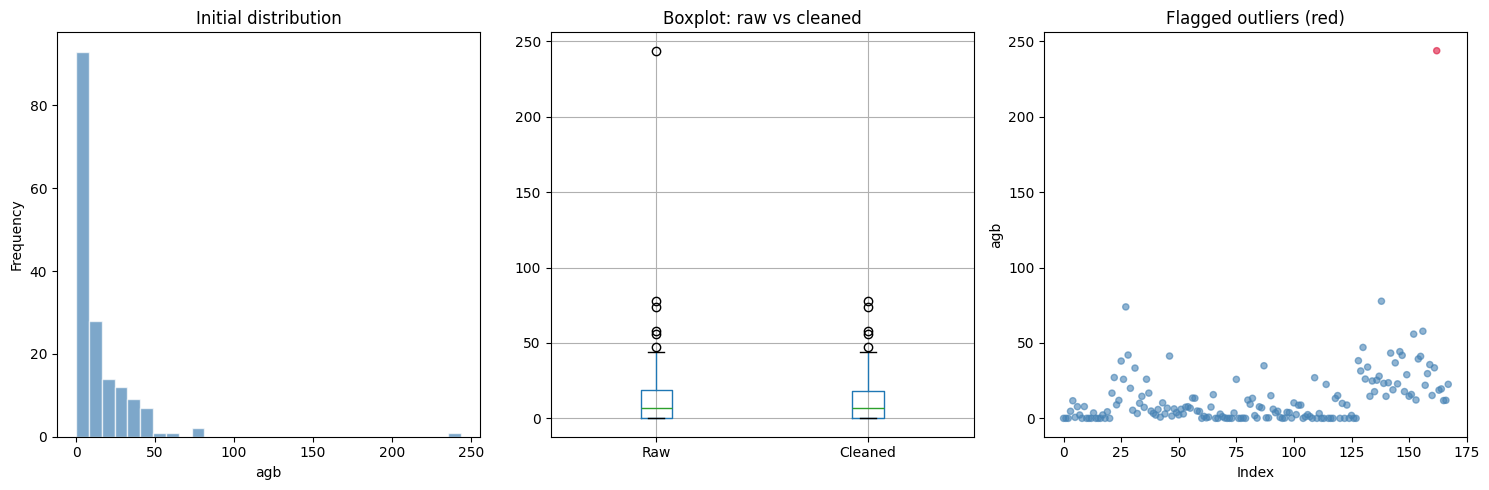

In [9]:
def outlier_report(
        y_arg, df_clean_arg, df_outliers_arg, 
        flags_arg, outlier_mask_arg
    ):
    """Print a summary of the outlier detection process."""
    print(f"Initial distribution ({TARGET})")
    print(f"  n={len(y_arg)}  min={y_arg.min():.2f}  mean={y_arg.mean():.2f}  "
          f"std={y_arg.std():.2f}  max={y_arg.max():.2f}  skew={y_arg.skew():.2f}")

    print(f"\nOutliers detected: {outlier_mask_arg.sum()} / {len(y_arg)} observations")
    print(f"  IQR             : {flags_arg['iqr'].sum()}")
    print(f"  Z-score         : {flags_arg['zscore'].sum()}")
    print(f"  Modified Z-score: {flags_arg['modified_zscore'].sum()}")
    print(f"  Consensus       : {outlier_mask_arg.sum()}")

    if len(df_outliers_arg) > 0:
        print("\nOutlier details:")
        print(df_outliers_arg[[TARGET, 'n_methods_flagged', 'flagged_by']].to_string())

    print(f"\nCleaned dataset: {len(df_clean_arg)} obs. | "
          f"max={df_clean_arg[TARGET].max():.2f} | mean={df_clean_arg[TARGET].mean():.2f}")
    print(f"Variance reduction: {np.var(y_arg) / np.var(df_clean_arg[TARGET]):.2f}x")

    # Comparative visualisation
    _, axes = plt.subplots(1, 3, figsize=(15, 5))

    y_arg.plot.hist(bins=30, ax=axes[0], color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].set_title("Initial distribution")
    axes[0].set_xlabel(TARGET)

    pd.DataFrame({'Raw': y_arg, 'Cleaned': df_clean_arg[TARGET]}).boxplot(ax=axes[1])
    axes[1].set_title("Boxplot: raw vs cleaned")

    colors = outlier_mask_arg.map({True: 'crimson', False: 'steelblue'})
    axes[2].scatter(range(len(y_arg)), y_arg, c=colors, alpha=0.6, s=20)
    axes[2].set_title("Flagged outliers (red)")
    axes[2].set_xlabel("Index")
    axes[2].set_ylabel(TARGET)

    plt.tight_layout()
    plt.show()

outlier_report(y, df_clean, df_outliers, flags, outlier_mask)


### Save field data

In [10]:
df_clean.to_csv(OUTPUT_CSV_FIELD, index=False)
print(f"Saved : {OUTPUT_CSV_FIELD}")
df_clean.info()

Saved : data/sen/dataset_agb_sedhiou_mission_janvier_2026.csv
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   inventory_date  167 non-null    object  
 1   latitude_proj   167 non-null    int64   
 2   longitude_proj  167 non-null    int64   
 3   agb             167 non-null    float64 
 4   cagb            167 non-null    float64 
 5   cagb_category   167 non-null    category
 6   HCS             167 non-null    str     
dtypes: category(1), float64(2), int64(2), object(1), str(1)
memory usage: 8.3+ KB


### HCSA Classes Repartition

In [11]:
df_clean["cagb_category"].value_counts(normalize=True)

cagb_category
OL     0.497006
S      0.149701
HDF    0.119760
YRF    0.113772
LDF    0.059880
MDF    0.059880
Name: proportion, dtype: float64

## Satellite Data

### Google Earth Engine authentication

In [12]:
CURRENT_DIR = "."
JSON_KEY_PATH = "secrets/gcp-sa-key.json"
key_path = os.path.join(CURRENT_DIR, JSON_KEY_PATH)

with open(key_path, "r", encoding="utf-8") as f:
    json_key_file = json.load(f)

credentials = ee.ServiceAccountCredentials(json_key_file['client_email'], key_path)
ee.Initialize(credentials)

print("Earth Engine initialized.")


Earth Engine initialized.


### Utility Functions

In [13]:
def add_polygon_geometry(row):
    """Buffer a point by RADIUS meters and return its bounding polygon."""
    aoi = ee.Geometry.Point([row['longitude'], row['latitude']]).buffer(RADIUS).bounds()
    aoi = aoi.getInfo()['coordinates'][0]
    return Polygon(aoi)

def get_period_boundaries(date):
    """Return the first and last day of the month for a given date string."""
    date = pd.to_datetime(date)
    month, year = date.month, date.year
    start_of_period = date.replace(day=1)
    if month < 12:
        end_of_period = date.replace(day=1, month=month + 1)
    else:
        end_of_period = date.replace(year=year + 1, day=1, month=1)
    return start_of_period.strftime('%Y-%m-%d'), end_of_period.strftime('%Y-%m-%d')

def create_polygon_geometry(row):
    """Convert a Shapely polygon geometry to an EE Geometry."""
    coords = list(row['geometry'].exterior.coords)
    return ee.Geometry.Polygon(coords)

def mask_edge(image):
    """Mask S1 image edges using a -30 dB threshold."""
    edge = image.lt(-30.0)
    masked_image = image.mask().And(edge.Not())
    return image.updateMask(masked_image)

def mask_s2_clouds(image):
    """Mask clouds and cirrus from S2 QA60 band, and scale reflectances."""
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )
    return image.updateMask(mask).divide(10000)

print("utility functions defined.")


utility functions defined.


### Load cleaned field data & build GeoDataFrame

In [14]:
field_data = pd.read_csv(INPUT_CSV_SAT)
field_data_copy = field_data.copy()

# Build GeoDataFrame from projected coordinates
gdf = gpd.GeoDataFrame(
    field_data_copy,
    geometry=gpd.points_from_xy(
        field_data_copy["longitude_proj"], field_data_copy["latitude_proj"]),
    crs=CRSP
)

# Reproject to WGS84 and extract lon/lat as plain columns
gdf_copy = gdf.to_crs(CRSG).copy()
gdf_copy['longitude'] = gdf_copy['geometry'].x
gdf_copy['latitude'] = gdf_copy['geometry'].y
gdf_copy.drop(columns=['geometry'], inplace=True)

# Add buffered polygon geometry and date boundaries
gdf_copy['geometry'] = gdf_copy.apply(add_polygon_geometry, axis=1)
gdf_copy['inventory_date'] = (
    pd.to_datetime(gdf_copy['inventory_date'], format="mixed")
    .dt.strftime('%Y-%m-%d')
)
gdf_copy[['start_date', 'end_date']] = gdf_copy['inventory_date'].apply(
    lambda x: pd.Series(get_period_boundaries(x))
)
gdf_copy = gpd.GeoDataFrame(gdf_copy, geometry='geometry', crs=CRSG)

print("GeoDataFrame ready.")
print(gdf_copy.info())
gdf_copy.head()


GeoDataFrame ready.
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   inventory_date  167 non-null    str     
 1   latitude_proj   167 non-null    int64   
 2   longitude_proj  167 non-null    int64   
 3   agb             167 non-null    float64 
 4   cagb            167 non-null    float64 
 5   cagb_category   167 non-null    str     
 6   HCS             167 non-null    str     
 7   longitude       167 non-null    float64 
 8   latitude        167 non-null    float64 
 9   geometry        167 non-null    geometry
 10  start_date      167 non-null    str     
 11  end_date        167 non-null    str     
dtypes: float64(4), geometry(1), int64(2), str(5)
memory usage: 15.8 KB
None


,inventory_date,latitude_proj,longitude_proj,agb,cagb,cagb_category,HCS,longitude,latitude,geometry,start_date,end_date
0,2026-01-15,1791714,389501,0.00,0.00,OL,non-HCS,-16.033787,16.203411,"POLYGON ((-16.03394 16.20327, -16.03364 16.203...",2026-01-01,2026-02-01
1,2026-01-15,1785136,391868,0.00,0.00,OL,non-HCS,-16.011342,16.144060,"POLYGON ((-16.01149 16.14392, -16.01119 16.143...",2026-01-01,2026-02-01
2,2026-01-15,1785256,390230,0.00,0.00,OL,non-HCS,-16.026666,16.145072,"POLYGON ((-16.02681 16.14493, -16.02652 16.144...",2026-01-01,2026-02-01
3,2026-01-15,1791718,389640,4.67,2.19,OL,non-HCS,-16.032487,16.203454,"POLYGON ((-16.03264 16.20331, -16.03234 16.203...",2026-01-01,2026-02-01
4,2026-01-15,1786002,390754,11.66,5.48,S,non-HCS,-16.021800,16.151838,"POLYGON ((-16.02195 16.15169, -16.02165 16.151...",2026-01-01,2026-02-01


### Extraction functions

In [15]:
def get_s1_placeholder():
    """Return a -9999 filled image with S1 band names."""
    imgs = [ee.Image.constant(NODATA).rename(b) for b in S1_BANDS]
    result = imgs[0]
    for img in imgs[1:]:
        result = result.addBands(img)
    return result

def get_s2_placeholder():
    """Return a -9999 filled image with S2 band names."""
    imgs = [ee.Image.constant(NODATA).rename(b) for b in S2_BANDS]
    result = imgs[0]
    for img in imgs[1:]:
        result = result.addBands(img)
    return result


def build_dataset(field_data_arg, bands):
    """Build dataset from a Field data and a list of bands."""

    # Build EE FeatureCollection
    ee_features = []
    for idx, row in field_data_arg.iterrows():
        coords = list(row['geometry'].exterior.coords)
        feat = ee.Feature(
            ee.Geometry.Polygon(coords),
            {
                'row_idx'    : int(idx),
                'start_date' : str(row['start_date']),
                'end_date'   : str(row['end_date'])
            }
        )
        ee_features.append(feat)

    fc = ee.FeatureCollection(ee_features)

    # Server-side processing
    def process_feature(feature):
        geom = feature.geometry()
        start_date = feature.getString('start_date')
        end_date = feature.getString('end_date')

        # Sentinel-1
        s1_collection = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(geom)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
            .map(mask_edge)
            .select(S1_BANDS)
        )

        # Sentinel-2
        s2_collection = (
            ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(geom)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', THRESHOLD))
            .map(mask_s2_clouds)
            .select(S2_BANDS)
        )

        s1_size = s1_collection.size()
        s2_size = s2_collection.size()

        # Use placeholder (-9999)
        s1_image = ee.Algorithms.If(
            s1_size.gt(0),
            s1_collection.mean().clip(geom),
            get_s1_placeholder()
        )
        s2_image = ee.Algorithms.If(
            s2_size.gt(0),
            s2_collection.median().clip(geom),
            get_s2_placeholder()
        )

        # DEM reprojected to 10m — S1 projection takes priority
        ref_proj = ee.Algorithms.If(
            s1_size.gt(0),
            ee.Image(s1_image).projection(),
            ee.Image(s2_image).projection()
        )
        elevation = (
            ee.Image('USGS/SRTMGL1_003')
            .select('elevation')
            .reproject(ee.Projection(ref_proj))
            .clip(geom)
        )

        combined = ee.Image.cat([
            ee.Image(s1_image),
            ee.Image(s2_image),
            elevation
        ])

        mean_stats = combined.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=10,
            maxPixels=1e8
        )

        has_data = s1_size.gt(0).Or(s2_size.gt(0))

        return feature.set(mean_stats).set('has_data', has_data)

    # Single server call
    try:
        results = fc.map(process_feature).getInfo()
    except Exception as e:
        print(f"GEE batch extraction failed : {e}")
        return field_data_arg.copy()

    # Rebuild DataFrame
    df_res = field_data_arg.copy()
    skipped_rows = []
    nan_report = {}

    for feature in results['features']:
        props = feature['properties']
        idx = props['row_idx']

        if not props.get('has_data', False):
            print(f"No imagery for row {idx}, all bands set to NaN.")
            skipped_rows.append(idx)

        missing = []
        for b in bands:
            raw = props.get(b, None)
            # Convert sentinel value and None to NaN
            if raw is None or raw == NODATA:
                value = np.nan
                missing.append(b)
            else:
                value = raw
            df_res.at[idx, b] = value

        if missing:
            nan_report[idx] = missing

    # Completeness report
    total = len(results['features'])
    n_skipped = len(skipped_rows)
    n_nan_rows = len(nan_report)

    print(f"\nExtraction complete — {total - n_skipped}/{total} rows with imagery.")
    if skipped_rows:
        print(f"Rows with no imagery     : {skipped_rows}")
    if nan_report:
        print(f"Rows with partial NaN    : {n_nan_rows} row(s)")
        for row_idx, missing_bands in list(nan_report.items())[:5]:
            print(f"    row {row_idx} → missing : {missing_bands}")

    # Drop geometry
    if 'geometry' in df_res.columns:
        df_res = df_res.drop(columns=['geometry'])

    return df_res

print("build_dataset defined.")


build_dataset defined.


### Run extraction

In [16]:
dataset = build_dataset(gdf_copy, S2_BANDS + S1_BANDS + DEM_BANDS)
print(f"Extracted dataset shape : {dataset.shape}")
dataset.info()



Extraction complete — 167/167 rows with imagery.
Extracted dataset shape : (167, 26)
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inventory_date  167 non-null    str    
 1   latitude_proj   167 non-null    int64  
 2   longitude_proj  167 non-null    int64  
 3   agb             167 non-null    float64
 4   cagb            167 non-null    float64
 5   cagb_category   167 non-null    str    
 6   HCS             167 non-null    str    
 7   longitude       167 non-null    float64
 8   latitude        167 non-null    float64
 9   start_date      167 non-null    str    
 10  end_date        167 non-null    str    
 11  B2              167 non-null    float64
 12  B3              167 non-null    float64
 13  B4              167 non-null    float64
 14  B8              167 non-null    float64
 15  B5              167 non-null    float64
 16  B6   

### Compute spectral & radar indices

In [17]:
dataset = add_s2_indices(dataset)
dataset = add_s1_indices(dataset)
print("Indices computed.")

dataset.to_csv(OUTPUT_CSV_SAT,  index=False)
gpd.GeoDataFrame(dataset).to_file(OUTPUT_GEOJSON, driver='GeoJSON')
print(f"Saved : {OUTPUT_CSV_SAT} and {OUTPUT_GEOJSON}")

dataset.info()


Indices computed.
Saved : data/sen/sen-biomass-dataset_s1_s2_dem_2026-06-10.csv and data/sen/sen-biomass-dataset_s1_s2_dem_2026-06-10.geojson
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 90 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inventory_date  167 non-null    str    
 1   latitude_proj   167 non-null    int64  
 2   longitude_proj  167 non-null    int64  
 3   agb             167 non-null    float64
 4   cagb            167 non-null    float64
 5   cagb_category   167 non-null    str    
 6   HCS             167 non-null    str    
 7   longitude       167 non-null    float64
 8   latitude        167 non-null    float64
 9   start_date      167 non-null    str    
 10  end_date        167 non-null    str    
 11  B2              167 non-null    float64
 12  B3              167 non-null    float64
 13  B4              167 non-null    float64
 14  B8              167 non-null    float64

## Train / Test Split

### Load dataset & stratified split

In [18]:
df = pd.read_csv(OUTPUT_CSV_SAT)

X = df.drop(columns=TARGET).copy()
y = df[TARGET].copy()

# Bin target for stratification
Q = len(BINS) - 1
y_binned = pd.qcut(y, q=Q, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_binned
)

print(f"Split complete : train={len(X_train)} obs | test={len(X_test)} obs")


Split complete : train=133 obs | test=34 obs


### Distribution comparison (KDE plot)

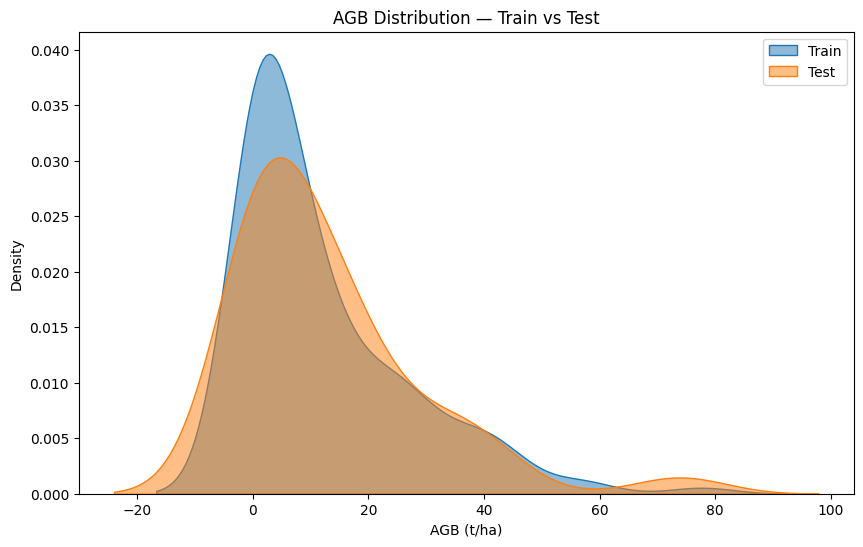

In [19]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_train, label='Train', fill=True, alpha=0.5)
sns.kdeplot(y_test,  label='Test',  fill=True, alpha=0.5)
plt.title('AGB Distribution — Train vs Test')
plt.xlabel('AGB (t/ha)')
plt.ylabel('Density')
plt.legend()
plt.show();

### Kolmogorov-Smirnov test

In [20]:
# Test whether train and test distributions are statistically similar
stat, p_value = stats.ks_2samp(y_train, y_test)

print(f"KS Statistic : {stat:.4f}")
print(f"P-value      : {p_value:.4f}")

if p_value > 0.05:
    print("Train and test distributions are statistically similar.")
else:
    print("Train and test distributions differ significantly.")


KS Statistic : 0.0953
P-value      : 0.9411
Train and test distributions are statistically similar.


### Save train / test sets

In [21]:
train_df = X_train.copy()
train_df[TARGET] = y_train

test_df = X_test.copy()
test_df[TARGET] = y_test

train_df.to_csv(TRAIN_FILE, index=False)
test_df.to_csv(TEST_FILE,  index=False)

print(f"train.csv saved — {len(train_df)} observations")
print(f"test.csv saved  — {len(test_df)} observations")


train.csv saved — 133 observations
test.csv saved  — 34 observations
